# CatalogIQ - Notebook 02: Teaching the computer to read a product photo

**The business problem.** A small seller photographs a product and has to fill in a form: what type of
product is it, which colour, for whom, for which season, for what occasion. Mistakes and blanks here hurt
search and cause returns. CatalogIQ's *Snap-to-Listing* feature looks at the photo and pre-fills the form.

**What this notebook shows**, in plain steps:
1. **Baselines first** - simple approaches we must beat, so we can tell whether our model really adds value.
2. **The model** - one network that looks at the photo once and answers all 7 questions.
3. **Test results** - scored on 6,339 photos the model never saw while learning.
4. **Knowing when it is unsure** - so the app can say "please confirm" instead of guessing.
5. **Understanding mistakes** - are they model failures or wrong labels in the catalog?
6. **Looking inside** - heatmaps of what the model looks at.
7. **Using it** - a `predict()` function and how fast it runs on a laptop CPU.

All logic lives in `src/catalogiq/vision/`; this notebook calls it and draws charts.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from catalogiq.config import get_config, get_vision_config, resolve_path
from catalogiq.vision.data import IGNORE_INDEX, build_image_cache, build_label_maps, encode_labels
from catalogiq.vision.evaluate import (confusion_top_k, expected_calibration_error, per_class_table,
                                       reliability_bins, score_target)
from catalogiq.vision.predict import AttributePredictor

cfg, v = get_config(), get_vision_config()
FIG = resolve_path(cfg["paths"]["reports_figures"])
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold", "font.size": 10})
COL = {"majority class": "#b9bec7", "frozen MobileNetV3 + logistic regression": "#e0a33a",
       "zero-shot CLIP ViT-B/32": "#6fa8d6", "multi-output MobileNetV3 (fine-tuned)": "#2f6fb0"}
TARGETS = v["targets"]
images, index = build_image_cache()
label_maps = json.loads((resolve_path(v["inference"]["model_dir"]) / v["inference"]["labels_file"]).read_text())
labels = encode_labels(index, label_maps)
split = index["split"].to_numpy()
test_pos = np.where(split == "test")[0]
y_test = {t: labels[t][test_pos].numpy() for t in TARGETS}
probs = dict(np.load(resolve_path("data/interim/test_probs_full.npz")))
print({s: int((split == s).sum()) for s in ("train", "val", "test")}, "photos per split")
print("classes per target:", {t: len(label_maps[t]) for t in TARGETS})

{'train': 29579, 'val': 6339, 'test': 6339} photos per split
classes per target: {'masterCategory': 4, 'subCategory': 25, 'articleType': 55, 'baseColour': 15, 'gender': 5, 'season': 4, 'usage': 6}


## 1. Baselines: the numbers to beat

Before building anything clever we measure three simple approaches on the **test** photos:

* **Majority class** - always answer the most common label (what a lazy system would do).
* **Frozen embeddings + logistic regression** - take a general-purpose, pre-trained image network
  (MobileNetV3, trained on ImageNet), freeze it, and train only a very simple classifier on its output.
* **Zero-shot CLIP** - a model that matches photos to sentences. No training on our data at all: we just ask
  "which is more similar, *a product photo of a t-shirt* or *a product photo of a watch*?"

**Metric used throughout:** *macro-F1* averages the score of every class equally, so rare product types
count as much as T-shirts. Plain accuracy would flatter a model that only gets common classes right.

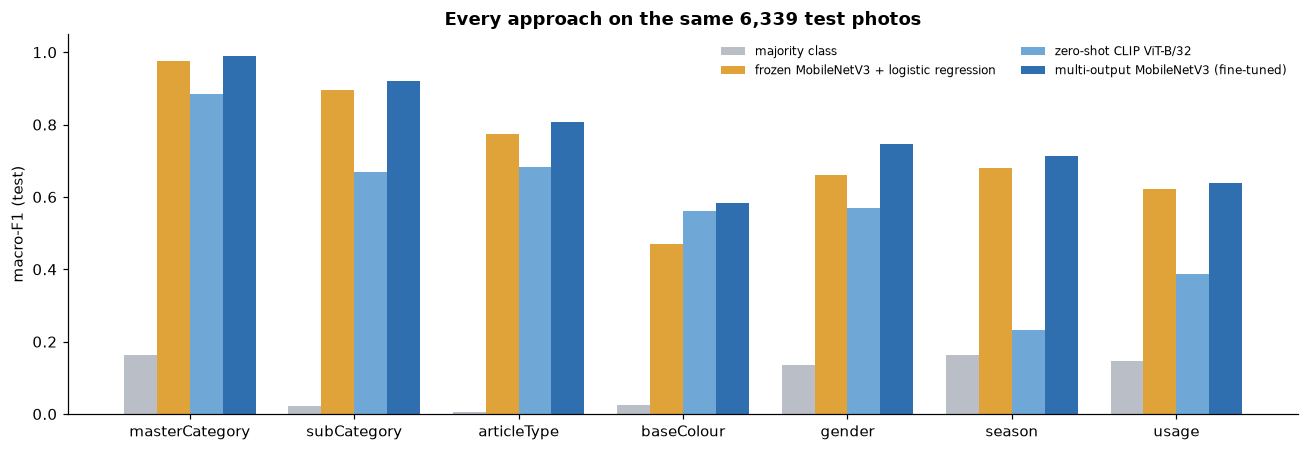

macro-F1 on test
model           majority class  frozen MobileNetV3 + logistic regression  zero-shot CLIP ViT-B/32  multi-output MobileNetV3 (fine-tuned)
target                                                                                                                                  
masterCategory           0.164                                     0.976                    0.883                                  0.990
subCategory              0.021                                     0.896                    0.668                                  0.922
articleType              0.005                                     0.775                    0.683                                  0.806
baseColour               0.025                                     0.469                    0.561                                  0.582
gender                   0.135                                     0.661                    0.570                                  0.747
season                  

In [2]:
comp = pd.read_csv(resolve_path("reports/model_vs_baselines.csv"))
order = ["majority class", "frozen MobileNetV3 + logistic regression", "zero-shot CLIP ViT-B/32",
         "multi-output MobileNetV3 (fine-tuned)"]
f1 = comp.pivot(index="target", columns="model", values="macro_f1").loc[TARGETS, order]
acc = comp.pivot(index="target", columns="model", values="accuracy").loc[TARGETS, order]
fig, ax = plt.subplots(figsize=(12, 4.2))
w = 0.2
for i, m in enumerate(order):
    ax.bar(np.arange(len(TARGETS)) + (i - 1.5) * w, f1[m], w, label=m, color=COL[m])
ax.set_xticks(range(len(TARGETS))); ax.set_xticklabels(TARGETS)
ax.set_ylabel("macro-F1 (test)"); ax.set_ylim(0, 1.05); ax.legend(frameon=False, fontsize=8, ncol=2)
ax.set_title("Every approach on the same 6,339 test photos")
plt.tight_layout(); plt.savefig(FIG / "09_model_vs_baselines.png", bbox_inches="tight"); plt.show()
print("macro-F1 on test"); print(f1.round(3).to_string())
print("\naccuracy on test"); print(acc.round(3).to_string())
print("\nmean macro-F1 over the 7 targets"); print(f1.mean().round(3).to_string())

**What we learned:** A generic pre-trained network with a very simple classifier on top is already a strong baseline: averaged over the 7 questions it scores macro-F1 0.725, versus 0.094 for always guessing the most common answer. Zero-shot CLIP (no training on our photos) scores 0.569 overall, but it is the best of the three baselines at **colour** (macro-F1 0.561 vs 0.469 for logistic regression), and it is weak where the answer is not a plain visual word: season 0.232 and usage 0.387. Simple approaches already reach 0.976 on top-level category and 0.896 on sub-category.

**Business takeaway:** The bar is high, so a trained model only earns its place if it clearly beats these numbers on the hard questions - product type (baseline 0.775), colour, gender, season and usage - and not on the easy top-level category. The CLIP result also tells us colour is where a generic network struggles most.

## 2. The model and how it was trained

**One network, seven answers.** A single pre-trained image network (MobileNetV3-Large) reads the photo once and
seven small "heads" each answer one question. Sharing the reading step is cheaper and lets the questions help
each other (a "watch" is never "Apparel").

**Why MobileNetV3-Large?** It is a small network (about 5 million adjustable numbers, a 13 MB file) designed
for phones and CPUs. This project must run on a laptop CPU with no graphics card, so speed matters more than
squeezing out the last percent of accuracy. We measured it: about 19 ms to process a photo.

**Two-step training (transfer learning).**
1. *Heads only:* keep the pre-trained network frozen, train just the seven heads (4 passes over the data).
2. *Fine-tune:* unfreeze the last blocks of the network and keep learning at a much lower learning rate so we
   adapt it to fashion photos without erasing what it already knows (6 passes).

**Imbalance: class weights instead of copying photos.** Rare classes get a bigger say in the learning signal
(weight proportional to 1/sqrt(class size)). We chose this over *oversampling* (duplicating rare photos)
because (a) our data already contains near-identical photos, and duplicating rare ones would make the model
memorise them rather than learn the product type, and (b) oversampling lengthens every training pass, and CPU
time is our scarcest resource. A square-root weight is a gentle middle: full inverse weighting would let a
handful of rare photos dominate.

**Augmentation (random edits while learning, so the model sees more variety):** mirror flips, small rotations
(+-10 degrees), small zoom/shifts, and slight brightness/contrast/saturation changes. We deliberately do
**not** change *hue* (the colour wheel position): shifting hue turns a navy shirt purple or a red one orange,
which would silently corrupt the very colour label we are trying to learn. A unit test enforces this.

**Safeguards.** Fixed random seed (42); the best pass is chosen by macro-F1 on a separate *validation* set
(never the test set); training stops early if that score stops improving; every run is logged in MLflow.

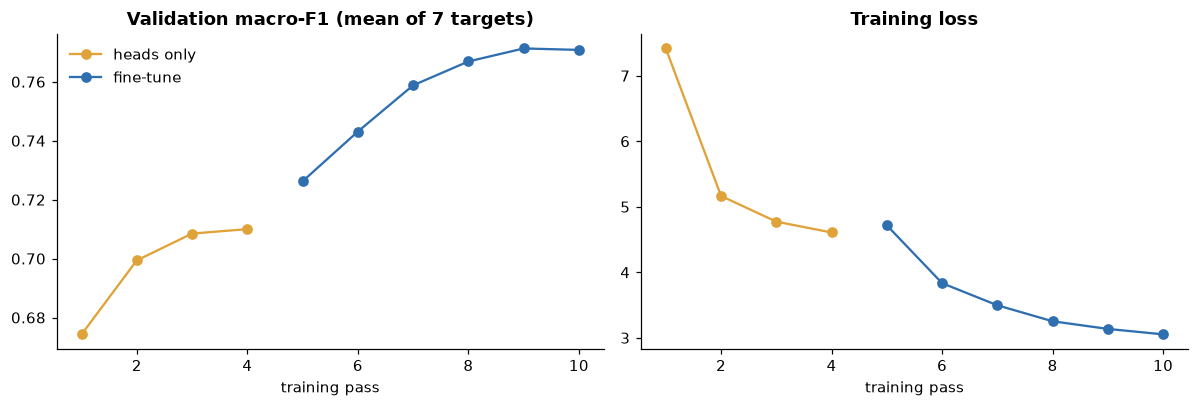

best validation macro-F1 0.7713 at stage2 pass 5
seconds per pass: {'stage1': 189.0, 'stage2': 291.0}
 stage  epoch  train_loss  val_macro_f1  seconds
stage1      1      7.4162        0.6743 185.0000
stage1      2      5.1649        0.6994 180.0000
stage1      3      4.7732        0.7085 192.0000
stage1      4      4.6079        0.7100 198.0000
stage2      1      4.7170        0.7262 289.0484
stage2      2      3.8345        0.7431 318.9331
stage2      3      3.4967        0.7588 324.2627
stage2      4      3.2529        0.7669 302.4028
stage2      5      3.1362        0.7713 275.7396
stage2      6      3.0534        0.7708 235.5903


In [3]:
h1 = pd.read_csv(resolve_path("reports/training_history_stage1_full.csv"))
h2 = pd.read_csv(resolve_path("reports/training_history_full.csv"))
h = pd.concat([h1, h2], ignore_index=True); h["pass"] = np.arange(1, len(h) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for st, c in (("stage1", "#e0a33a"), ("stage2", "#2f6fb0")):
    d = h[h["stage"] == st]
    axes[0].plot(d["pass"], d["val_macro_f1"], "o-", color=c, label={"stage1": "heads only", "stage2": "fine-tune"}[st])
    axes[1].plot(d["pass"], d["train_loss"], "o-", color=c)
axes[0].set_title("Validation macro-F1 (mean of 7 targets)"); axes[0].set_xlabel("training pass"); axes[0].legend(frameon=False)
axes[1].set_title("Training loss"); axes[1].set_xlabel("training pass")
plt.tight_layout(); plt.savefig(FIG / "10_training_curves.png", bbox_inches="tight"); plt.show()
best = h.loc[h["val_macro_f1"].idxmax()]
print(f"best validation macro-F1 {best['val_macro_f1']:.4f} at {best['stage']} pass {int(best['epoch'])}")
print("seconds per pass:", h.groupby("stage")["seconds"].mean().round(0).to_dict())
print(h[["stage", "epoch", "train_loss", "val_macro_f1", "seconds"]].round(4).to_string(index=False))

**What we learned:** Training the heads alone lifts validation macro-F1 to 0.710 (4 passes, about 189 seconds each). Fine-tuning the last blocks then lifts it to 0.771, the best pass being the 5th of 6 (0.7713); the 6th (0.7708) did not improve, so we stopped at the point of diminishing returns. Fine-tuning passes took about 291 seconds each, so the whole run is roughly 42 minutes of CPU time. One honest note: the first run was killed by an unexpected interruption during fine-tuning, so we resumed fine-tuning from the saved heads-only checkpoint; the numbers above are from the resumed run.

**Business takeaway:** A capable product-photo model can be trained in well under an hour on an ordinary laptop with no graphics card, which keeps the cost of retraining on a marketplace's own photos low.

## 3. Test results, per target

In [4]:
rows = []
for t in TARGETS:
    s = score_target(y_test[t], probs[t])
    rows.append({"target": t, "classes": len(label_maps[t]), **{k: round(x, 4) for k, x in s.items()}})
main = pd.DataFrame(rows).set_index("target")
base = comp[comp["model"] == "majority class"].set_index("target")
lr = comp[comp["model"] == "frozen MobileNetV3 + logistic regression"].set_index("target")
main["majority_acc"] = base["accuracy"]
main["lift_vs_majority_acc"] = (main["accuracy"] - main["majority_acc"]).round(4)
main["macroF1_gain_vs_logreg"] = (main["macro_f1"] - lr["macro_f1"]).round(4)
main

,classes,accuracy,macro_f1,weighted_f1,top3_accuracy,majority_acc,lift_vs_majority_acc,macroF1_gain_vs_logreg
target,,,,,,,,
masterCategory,4,0.9915,0.9899,0.9915,0.9994,0.4901,0.5014,0.0142
subCategory,25,0.9590,0.9216,0.9601,0.9950,0.3619,0.5971,0.0257
articleType,55,0.8566,0.8060,0.8545,0.9751,0.1672,0.6894,0.0313
baseColour,15,0.6750,0.5821,0.6761,0.9047,0.2292,0.4458,0.1130
gender,5,0.8781,0.7474,0.8806,0.9926,0.5073,0.3708,0.0865
season,4,0.6990,0.7141,0.6976,0.9834,0.4892,0.2098,0.0351
usage,6,0.8763,0.6391,0.8800,0.9972,0.7801,0.0962,0.0168


**What we learned:** On 6,339 photos the model never saw, the fine-tuned model beats the logistic-regression baseline on macro-F1 for **all seven** targets (mean 0.771 vs 0.725; the gain ranges from +0.014 for top-level category to +0.113 for colour). Product type reaches 85.7% accuracy (macro-F1 0.806) and the correct type is among the model's top 3 guesses 97.5% of the time. Top-level category is 99.2% and sub-category 95.9%. The weaker targets are colour (67.5% accuracy, macro-F1 0.582), season (69.9%, 21 points above always guessing 'Summer') and usage (87.6%, only 9.6 points above always guessing 'Casual'). Remember colour labels are noisy: in Phase 1, 44% of look-alike photo groups disagreed on colour.

**Business takeaway:** Snap-to-Listing can reliably pre-fill the catalog hierarchy and gender, and can offer three product-type suggestions that contain the right one 97.5% of the time. Colour, season and usage are useful hints but not facts. All seven beat the 'always guess the biggest class' bar we set in Phase 1.

### Where the confusion is: product type, top 15 classes

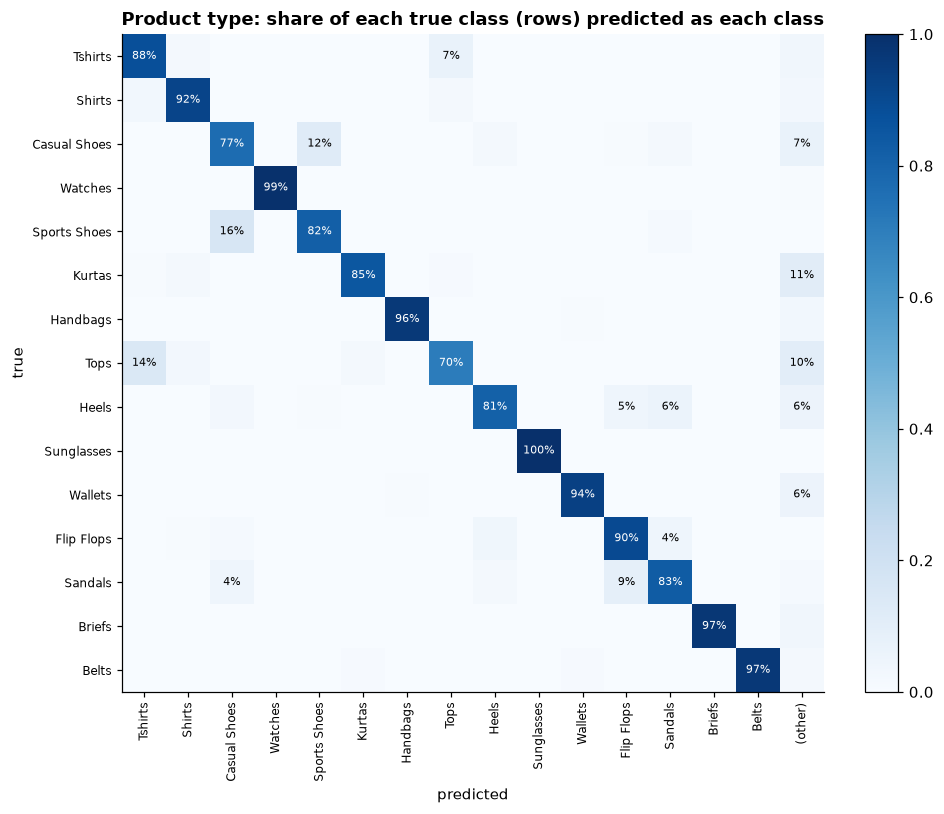

largest off-diagonal confusions (>=8% of the true class):
  Sports Shoes   -> Casual Shoes   16%
  Tops           -> Tshirts        14%
  Casual Shoes   -> Sports Shoes   12%
  Kurtas         -> (other)        11%
  Tops           -> (other)        10%
  Sandals        -> Flip Flops     9%


In [5]:
cm, names = confusion_top_k(y_test["articleType"], probs["articleType"], label_maps["articleType"], k=15)
norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_yticks(range(len(names) - 1)); ax.set_yticklabels(names[:-1], fontsize=8)
for i in range(norm.shape[0]):
    for j in range(norm.shape[1]):
        if norm[i, j] >= 0.04:
            ax.text(j, i, f"{norm[i, j]:.0%}", ha="center", va="center", fontsize=7,
                    color="white" if norm[i, j] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Product type: share of each true class (rows) predicted as each class")
plt.colorbar(im, fraction=0.04); plt.tight_layout(); plt.savefig(FIG / "11_confusion_articleType.png", bbox_inches="tight"); plt.show()
off = [(names[i], names[j], norm[i, j]) for i in range(norm.shape[0]) for j in range(norm.shape[1]) if i != j and norm[i, j] >= 0.08]
print("largest off-diagonal confusions (>=8% of the true class):")
for a, b, x in sorted(off, key=lambda r: -r[2]): print(f"  {a:14s} -> {b:14s} {x:.0%}")

### Per-class precision and recall (product type)

In [6]:
pc = per_class_table(y_test["articleType"], probs["articleType"], label_maps["articleType"])
big = pc[pc["support"] >= 30]
print(f"{len(pc)} classes; {len(big)} have at least 30 test photos")
print("\nBest 8 classes by F1 (support >= 30):"); print(big.sort_values("f1", ascending=False).head(8).round(3).to_string(index=False))
print("\nWeakest 10 classes by F1 (support >= 30):"); print(big.sort_values("f1").head(10).round(3).to_string(index=False))
print("\nClasses with F1 < 0.5:", pc[pc["f1"] < 0.5][["class", "f1", "support"]].round(3).values.tolist())

55 classes; 40 have at least 30 test photos

Best 8 classes by F1 (support >= 30):
     class  precision  recall    f1  support
Sunglasses      0.988   1.000 0.994      162
   Watches      0.992   0.995 0.993      381
       Bra      0.986   1.000 0.993       72
  Lipstick      1.000   0.978 0.989       46
      Ties      1.000   0.972 0.986       36
     Socks      0.990   0.980 0.985      102
     Belts      1.000   0.967 0.983      121
    Sarees      0.969   0.984 0.977       64

Weakest 10 classes by F1 (support >= 30):
          class  precision  recall    f1  support
          Flats      0.423   0.147 0.218       75
         Tunics      0.241   0.206 0.222       34
         Kurtis      0.325   0.371 0.347       35
       Sweaters      0.463   0.452 0.458       42
        Jackets      0.586   0.436 0.500       39
    Sweatshirts      0.500   0.571 0.533       42
           Tops      0.604   0.705 0.650      264
        Dresses      0.676   0.696 0.686       69
       Clutches    

**What we learned:** The model is excellent on products with a distinctive shape: sunglasses, watches, bras, lipstick, ties, socks, belts and sarees all score F1 of 0.977 or more. The main confusions are between classes people also find blurry: sports shoes predicted as casual shoes (16% of sports shoes) and the reverse (12%), tops predicted as T-shirts (14%), sandals predicted as flip flops (9%). Among the 40 classes with at least 30 test photos, the weakest are Flats (F1 0.218), Tunics (0.222), Kurtis (0.347), Sweaters (0.458), Jackets (0.500) and Sweatshirts (0.533); five classes in total score below 0.5. Fifteen classes have fewer than 30 test photos, so their scores are noisy.

**Business takeaway:** The weak classes are the ones separated by cut, sleeve length or fabric detail that a 60x80-pixel thumbnail cannot show. For these the product should offer the model's top suggestions and let the seller choose, while the sub-category (95.9%) can be filled in automatically.

## 4. Knowing when it is unsure

A model that is right 86% of the time is also wrong 14% of the time, and in a seller tool a confident wrong
answer is worse than "please check this". Every prediction comes with a **confidence** (0-100%). Two things
matter:

* **Is the confidence honest?** If the model says 80%, it should be right about 80% of the time. This is
  *calibration*, measured by **ECE** (average gap between confidence and actual accuracy; 0 = perfect).
  We also fit one "temperature" number per target on the *validation* photos that rescales over/under-confidence.
* **Where do we draw the line?** For each target we choose a **confidence threshold** on the validation photos:
  the lowest one where the answers we auto-fill are right at least 90% of the time. Anything below it is shown as
  *"Not sure - please confirm"*.

**This is a product decision, not a math one: precision vs coverage.** A high threshold means almost every
auto-filled value is right (high *precision*) but the seller must confirm many fields (low *coverage*, more
work). A low threshold fills in more fields automatically but lets more mistakes through. The 90% bar is our
starting point; a marketplace that fears returns would raise it, one that wants frictionless uploads would lower it.

        target  temperature  ece_before  ece_after  threshold  test_coverage  test_precision_of_accepted
masterCategory        0.914      0.0018     0.0026     0.3411         1.0000                      0.9915
   subCategory        0.887      0.0132     0.0074     0.1869         1.0000                      0.9590
   articleType        0.905      0.0158     0.0139     0.4947         0.9285                      0.8904
    baseColour        0.995      0.0170     0.0160     0.7648         0.3983                      0.8848
        gender        0.950      0.0104     0.0119     0.4898         0.9661                      0.8940
        season        0.976      0.0239     0.0203     0.7911         0.2912                      0.9030
         usage        0.913      0.0211     0.0178     0.6010         0.9221                      0.9008


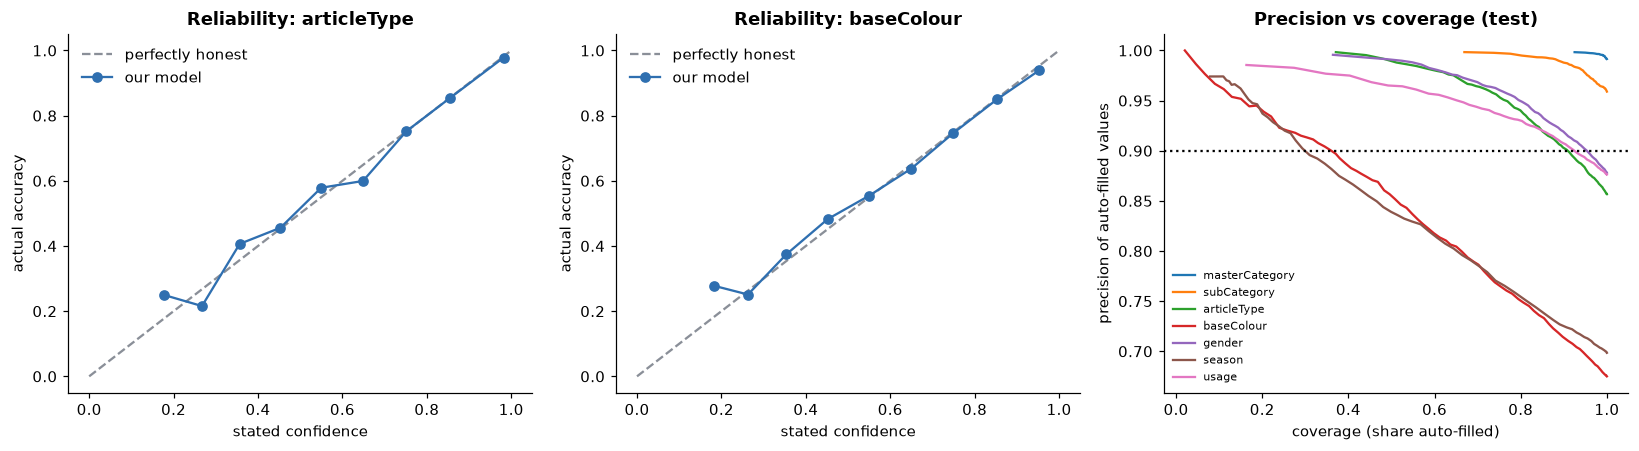

In [7]:
calib = pd.read_csv(resolve_path("reports/calibration.csv"))
print(calib.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, t in zip(axes[:2], ["articleType", "baseColour"]):
    rb = reliability_bins(y_test[t], probs[t], 10)
    ax.plot([0, 1], [0, 1], "--", color="#8a8f98", label="perfectly honest")
    ax.plot(rb["mean_confidence"], rb["accuracy"], "o-", color="#2f6fb0", label="our model")
    ax.set_title(f"Reliability: {t}"); ax.set_xlabel("stated confidence"); ax.set_ylabel("actual accuracy")
    ax.legend(frameon=False)
ax = axes[2]
for t in TARGETS:
    conf = probs[t].max(1); ok = probs[t].argmax(1) == y_test[t]
    thr = np.linspace(0, 0.99, 100)
    cov = [(conf >= x).mean() for x in thr]; prec = [ok[conf >= x].mean() if (conf >= x).any() else np.nan for x in thr]
    ax.plot(cov, prec, label=t)
ax.axhline(0.9, ls=":", color="k"); ax.set_xlabel("coverage (share auto-filled)"); ax.set_ylabel("precision of auto-filled values")
ax.set_title("Precision vs coverage (test)"); ax.legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.savefig(FIG / "12_calibration_and_tradeoff.png", bbox_inches="tight"); plt.show()

**What we learned:** The model's confidence is already honest: before any adjustment the calibration error (ECE) is only 0.2 to 2.4 percentage points per target. Temperature scaling improved it modestly for sub-category (0.0132 to 0.0074), usage (0.0211 to 0.0178) and season (0.0239 to 0.0203) and made it slightly worse for top-level category (0.0018 to 0.0026) and gender (0.0104 to 0.0119), because it optimises a different measure; all temperatures are close to 1 (0.89 to 0.995). Using thresholds chosen on validation photos for a 90% precision target, the test results are: product type auto-filled for 92.9% of photos at 89.0% correct, gender 96.6% at 89.4%, usage 92.2% at 90.1%, but colour only 39.8% at 88.5% and season only 29.1% at 90.3%. Top-level category and sub-category need no threshold (99.2% and 95.9% correct overall). Three targets land slightly under the 90% bar on test (88.5% to 89.4%) because the threshold was tuned on a different set of photos.

**Business takeaway:** We can honestly tell sellers 'not sure - please confirm' for the right photos. The cost is visible: for colour and season most uploads would still need a confirmation click at a 90% quality bar. The right-hand chart shows the whole trade-off curve per target, so the marketplace can choose its own point - stricter to cut returns, looser to make uploading frictionless.

## 5. Understanding the mistakes

For product type, 909 of 6,339 test photos are wrong. Are those the model's fault? We looked at the
**24 most confident wrong predictions** and at **40 randomly chosen wrong predictions**, and sorted each into:

* **wrong label** - the catalog's label is plainly wrong and the model is right (e.g. a pair of briefs labelled "Sports Shoes");
* **ambiguous boundary** - a genuinely blurry line between two classes (casual vs sports shoes, tops vs T-shirts, clutch vs handbag);
* **model error** - the label is reasonable and the model is wrong;
* **image problem** - unusable or corrupted picture.

*Honesty note: these judgements were made by one reviewer (the AI assistant), looking at 60x80-pixel thumbnails.
They are indicative, not ground truth, and with only 40 random cases the percentages carry wide error bars.*

category         ambiguous_boundary  image_problem  model_error  wrong_label
source                                                                      
random40                         27              0            9            4
top24_confident                  13              1            0           10

random40 {'ambiguous_boundary': 67.5, 'model_error': 22.5, 'wrong_label': 10.0}
top24_confident {'ambiguous_boundary': 54.2, 'wrong_label': 41.7, 'image_problem': 4.2}

articleType test errors: 909 of 6339 (14.3%)
  extrapolated wrong_label          ~    91 errors (10% of errors, 1.4% of all test photos)
  extrapolated ambiguous_boundary   ~   614 errors (68% of errors, 9.7% of all test photos)
  extrapolated model_error          ~   205 errors (22% of errors, 3.2% of all test photos)
accuracy if plainly-mislabelled photos were counted correct: ~87.1%


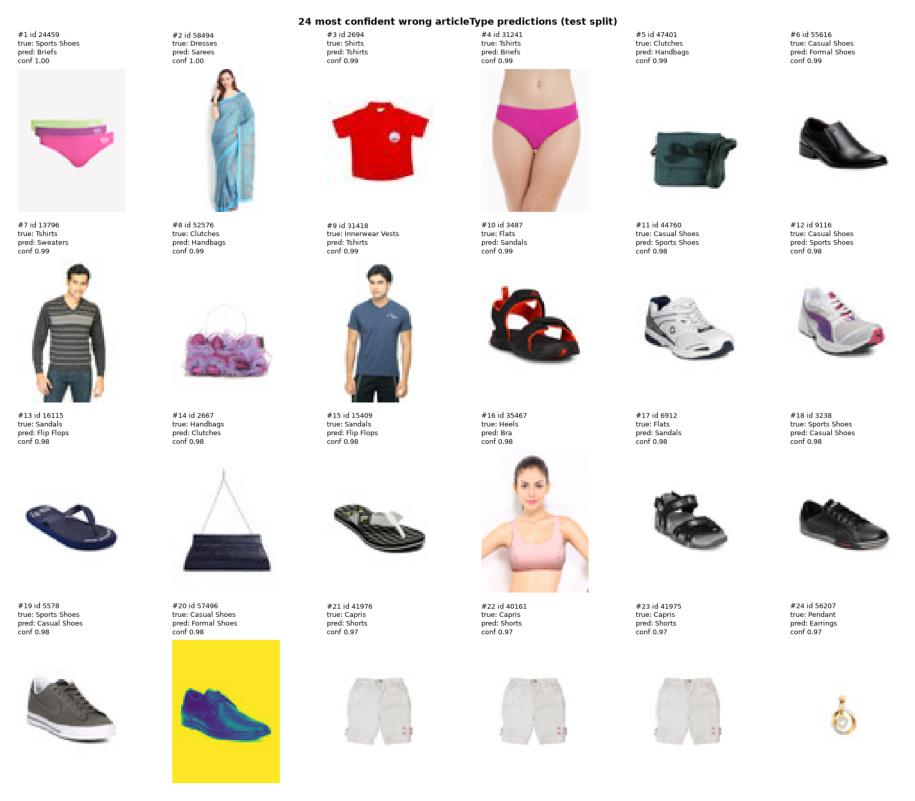

In [8]:
review = pd.read_csv(resolve_path("reports/error_review.csv"))
tab = review.groupby(["source", "category"]).size().unstack(fill_value=0)
print(tab.to_string()); print()
for src, d in review.groupby("source"):
    print(src, (d["category"].value_counts(normalize=True) * 100).round(1).to_dict())
n_err = int((probs["articleType"].argmax(1) != y_test["articleType"]).sum())
rnd = review[review["source"] == "random40"]["category"].value_counts(normalize=True)
print(f"\narticleType test errors: {n_err} of {len(y_test['articleType'])} ({n_err / len(y_test['articleType']):.1%})")
for cat in ("wrong_label", "ambiguous_boundary", "model_error"):
    share = float(rnd.get(cat, 0))
    print(f"  extrapolated {cat:20s} ~ {share * n_err:5.0f} errors ({share:.0%} of errors, {share * n_err / len(y_test['articleType']):.1%} of all test photos)")
n_ok = len(y_test["articleType"]) - n_err
print(f"accuracy if plainly-mislabelled photos were counted correct: ~{(n_ok + float(rnd.get('wrong_label', 0)) * n_err) / len(y_test['articleType']):.1%}")
fig = plt.figure(figsize=(14, 9.2)); plt.imshow(Image.open(FIG / "06_confident_errors.png")); plt.axis("off"); plt.show()

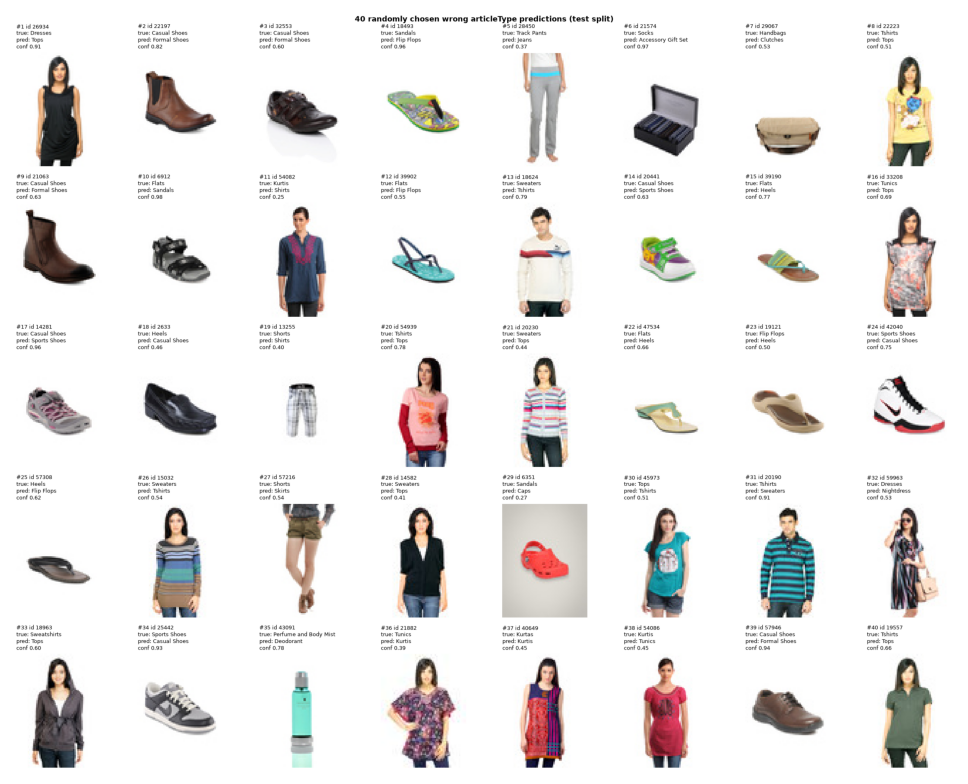

In [9]:
fig = plt.figure(figsize=(14, 9)); plt.imshow(Image.open(FIG / "07_random_errors.png")); plt.axis("off"); plt.show()

**What we learned:** Product type is wrong on 909 of 6,339 test photos (14.3%). Of the 24 most confident mistakes, 10 are plainly wrong catalog labels where the model is right (briefs labelled 'Sports Shoes', a saree labelled 'Dresses', a sports bra labelled 'Heels', a striped sweater labelled 'T-shirts'), 13 are genuinely blurry class boundaries and 1 is a corrupted image. Among 40 randomly chosen mistakes, 4 (10%) are plain label errors, 27 (67.5%) are ambiguous boundaries (casual/sports/formal shoes, tops/T-shirts, kurtis/tunics, clutch/handbag) and 9 (22.5%) are real model errors such as track pants read as jeans or shorts read as a skirt. Extrapolated to all 909 mistakes: about 91 plain label errors (1.4% of all test photos), about 614 boundary cases (9.7%) and about 205 real model errors (3.2%); counting the mislabelled photos as correct would lift accuracy from 85.7% to roughly 87.1%. We found no clear multi-item photo problem in these samples. Caveat: one reviewer (the AI assistant), small thumbnails and only 40 random cases, so the percentages are indicative with wide error bars, and some 'ambiguous' cases may be real model errors.

**Business takeaway:** Most of the remaining error is not the model being dumb - it is a fuzzy product taxonomy and some bad labels. The fix is clearer category definitions (for example when is a shoe 'casual' vs 'sports'), keeping seller confirmation for boundary classes, and using confident disagreements as an automatic **catalog-cleaning to-do list**, which is exactly what the image-text mismatch check in the quality feature will do.

## 6. Looking inside: what does the model look at?

**Grad-CAM** colours the parts of a photo that pushed the model toward its answer (red = strong influence).
The top row shows correct predictions, the bottom row confident mistakes. The heatmap is coarse (the network
sees a 60x80-pixel photo through an 8x6 grid) so read it as "roughly where", not "exactly which pixel".

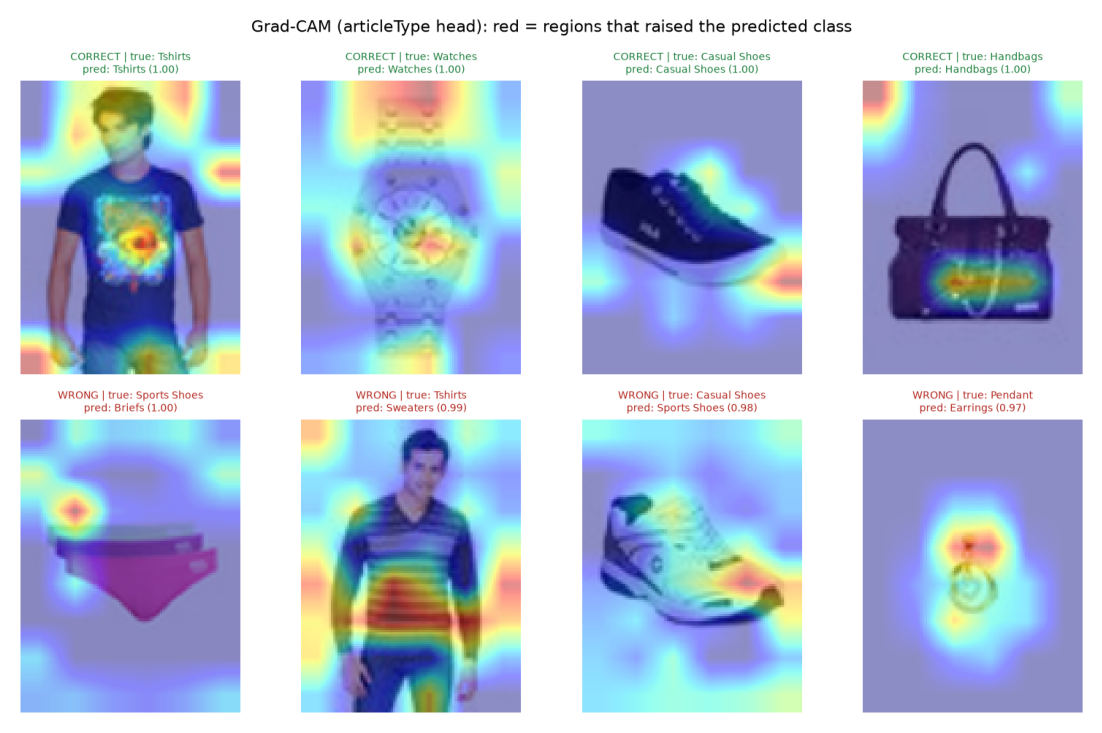

In [10]:
fig = plt.figure(figsize=(13, 8.4)); plt.imshow(Image.open(FIG / "08_gradcam.png")); plt.axis("off"); plt.show()

**What we learned:** For correct predictions the model attends to sensible regions: the printed graphic on the T-shirt, the dial of the watch, the body of the handbag. It is not perfect - on the T-shirt some attention also falls on the model's face and the background, so part of the 'T-shirt' decision is context ('a person wearing a top'). For the mistakes, the heatmaps explain the call: the striped torso drives 'Sweaters' for a striped long-sleeve top labelled T-shirt, and the small loop of a pendant drives 'Earrings'. For the briefs labelled 'Sports Shoes' the model is looking at the briefs, i.e. the label is the problem. The maps are coarse (an 8x6 grid on a 60x80-pixel photo), so they show roughly where, not exactly which pixels.

**Business takeaway:** The model is mostly looking at the product, which builds trust, and the heatmaps give catalog teams a quick way to see why a prediction disagrees with a label.

## 7. Using the model: `predict()` and speed

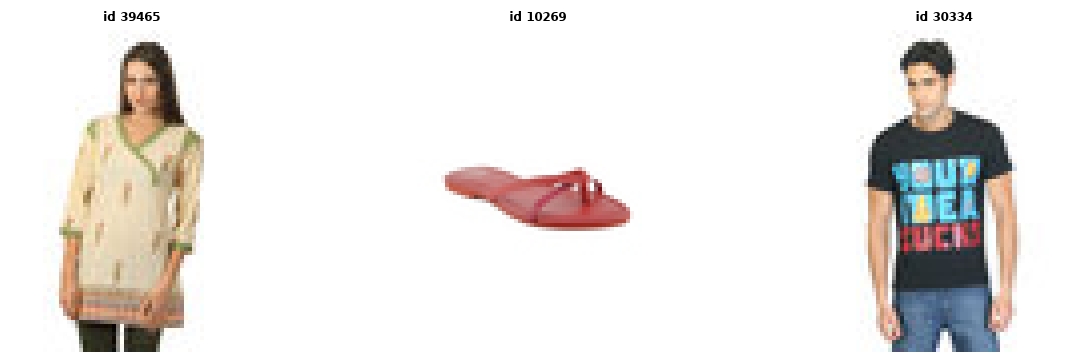

   id      attribute     true  predicted  confidence  needs_review
39465 masterCategory  Apparel    Apparel       0.985         False
39465    subCategory  Topwear    Topwear       0.970         False
39465    articleType   Kurtis     Kurtis       0.418          True
39465     baseColour    Beige      Beige       0.724          True
39465         gender    Women      Women       0.998         False
39465         season   Summer     Summer       0.882         False
39465          usage   Ethnic     Ethnic       0.983         False
10269 masterCategory Footwear   Footwear       0.999         False
10269    subCategory    Shoes Flip Flops       0.812         False
10269    articleType    Flats Flip Flops       0.755         False
10269     baseColour      Red        Red       0.489          True
10269         gender    Women      Women       0.521         False
10269         season   Winter     Summer       0.348          True
10269          usage   Casual     Casual       0.985         F

In [11]:
predictor = AttributePredictor()
rng = np.random.default_rng(cfg["project"]["seed"])
ids = index["id"].to_numpy()
sample = rng.choice(test_pos, 3, replace=False)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4)); out_rows = []
for ax, p in zip(axes, sample):
    ax.imshow(images[p]); ax.axis("off"); ax.set_title(f"id {ids[p]}", fontsize=8)
    pred = predictor.predict(images[p])
    for t, (lab, conf, review_flag) in pred.items():
        truth = index.iloc[p][t]
        out_rows.append({"id": ids[p], "attribute": t, "true": truth, "predicted": lab,
                         "confidence": round(conf, 3), "needs_review": review_flag})
plt.tight_layout(); plt.show()
print(pd.DataFrame(out_rows).to_string(index=False))
lat = json.loads(resolve_path("reports/latency.json").read_text())
print("\nCPU latency per image (preprocessing included):", {k: round(x, 1) if isinstance(x, float) else x for k, x in lat.items() if k != "note"})
print("note:", lat["note"])

**What we learned:** `predict(image)` returns, for each of the 7 attributes, the label, a calibrated confidence and a `needs_review` flag. In the three random test photos above, season and colour are often flagged for review while category and gender mostly are not, as designed. One photo shows the limits: the catalog says the shoe is 'Flats' while the model says 'Flip Flops' (0.755), a real boundary case that is not flagged. Speed on this laptop's CPU (an emulated x64 Python on an ARM64 chip, so likely a pessimistic figure): 18.7 ms on average and 22.2 ms at the 95th percentile per photo including image preparation, from a 12.9 MB exported model.

**Business takeaway:** The photo is analysed in about a fiftieth of a second on a laptop with no graphics card, so Snap-to-Listing can respond instantly while a seller fills in the form.

## 8. Decision: which attributes does Snap-to-Listing publish?

In [12]:
dec = main[["accuracy", "majority_acc", "lift_vs_majority_acc", "macro_f1"]].join(
    calib.set_index("target")[["threshold", "test_coverage", "test_precision_of_accepted"]])
# Rule of thumb (a product decision, easy to change): auto-fill only when (a) at least 90% of photos clear the
# 90%-precision bar AND (b) macro-F1 >= 0.70, i.e. rare classes are also handled, not just the common ones.
auto = (dec["test_coverage"] >= 0.9) & (dec["macro_f1"] >= 0.70)
dec["ui_behaviour"] = np.where(auto, "auto-fill, flag low-confidence", "suggest, ask seller to confirm")
dec.round(3)

,accuracy,majority_acc,lift_vs_majority_acc,macro_f1,threshold,test_coverage,test_precision_of_accepted,ui_behaviour
target,,,,,,,,
masterCategory,0.992,0.490,0.501,0.990,0.341,1.000,0.992,"auto-fill, flag low-confidence"
subCategory,0.959,0.362,0.597,0.922,0.187,1.000,0.959,"auto-fill, flag low-confidence"
articleType,0.857,0.167,0.689,0.806,0.495,0.928,0.890,"auto-fill, flag low-confidence"
baseColour,0.675,0.229,0.446,0.582,0.765,0.398,0.885,"suggest, ask seller to confirm"
gender,0.878,0.507,0.371,0.747,0.490,0.966,0.894,"auto-fill, flag low-confidence"
season,0.699,0.489,0.210,0.714,0.791,0.291,0.903,"suggest, ask seller to confirm"
usage,0.876,0.780,0.096,0.639,0.601,0.922,0.901,"suggest, ask seller to confirm"


**What we learned and decision:** All seven attributes beat the 'always guess the biggest class' bar, so all seven are published. The rule above is a product choice: auto-fill only if at least 90% of photos clear the 90%-precision threshold and macro-F1 is at least 0.70. That makes top-level category, sub-category, product type and gender **auto-fill with a low-confidence flag**, while **colour, season and usage are suggestions the seller confirms**: colour and season because only about 40% and 29% of photos clear the bar, usage because it is only 9.6 points better than always guessing 'Casual' (macro-F1 0.639).

**Business takeaway:** This matches how a seller would trust an assistant: it fills in the obvious things and asks about the judgement calls. The thresholds and the 0.70 / 90% rules are product settings and can be tightened or loosened as the marketplace learns what its sellers prefer.

## Summary and next steps

See the takeaways above and `docs/model_card_classifier.md`. Next phase: use this model's visual understanding
(and CLIP embeddings) for visual search - similar products, "shop the look" and duplicate detection.